# Network Intrusion Detection System (NIDS) — End-to-End ML Pipeline

**Pipeline phases**

1. Data Loading
2. Data Cleaning & EDA
3. Feature Engineering
4. Train-Test Split
5. Model Training (baselines)
6. Model Evaluation
7. Hyperparameter Tuning ⭐
8. Final Model Evaluation
9. Explainable AI (SHAP)
10. Save Model & Artifacts

This notebook is written to be production-oriented: a central `CONFIG`, reusable
functions, reproducible seeds, saved artifacts (scaler / encoder / model / metrics),
and a final inference-ready model bundle.


## 0. Setup — Imports & Configuration

In [1]:

# Core
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing / modeling
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from cloud.blob_storage.blob_client import load_csv_from_blob, list_blobs

import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


ENV PATH: E:\NIDS\cloud\blob_storage\.env
ENV Exists: True
Connection String Loaded: True
Container Name: raw-data


In [2]:
import os

print(os.getcwd())

e:\NIDS


In [3]:

# ------------------------------------------------------------------
# Central configuration — change paths/params here only
# ------------------------------------------------------------------
CONFIG = {
    "raw_data_dir": Path("dataset/raw/data"),
    "processed_dir": Path("dataset/processed_data"),
    "models_dir": Path("models"),
    "reports_dir": Path("reports"),
    "label_col_candidates": ["Label", " Label"],   # CICIDS-style files often have a leading space
    "test_size": 0.2,
    "random_state": RANDOM_STATE,
    "corr_threshold": 0.95,
    "n_cv_folds": 5,
    "shap_sample_size": 2000,   # SHAP on a subsample for speed on large NIDS datasets
    "hpo_sample_size": 150_000,  # subsample used ONLY for the hyperparameter search (memory safety)
    "hpo_n_jobs": 2,              # process-based parallelism -> each worker copies the data, keep this LOW
    "hpo_n_iter": 25,
}

# Create output directories up-front (idempotent)
for d in [CONFIG["processed_dir"], CONFIG["models_dir"], CONFIG["reports_dir"]]:
    d.mkdir(parents=True, exist_ok=True)

CONFIG


{'raw_data_dir': WindowsPath('dataset/raw/data'),
 'processed_dir': WindowsPath('dataset/processed_data'),
 'models_dir': WindowsPath('models'),
 'reports_dir': WindowsPath('reports'),
 'label_col_candidates': ['Label', ' Label'],
 'test_size': 0.2,
 'random_state': 42,
 'corr_threshold': 0.95,
 'n_cv_folds': 5,
 'shap_sample_size': 2000,
 'hpo_sample_size': 150000,
 'hpo_n_jobs': 2,
 'hpo_n_iter': 25}

## Phase 1 — Data Loading

Reads every CSV in the raw data folder and concatenates them into a single dataframe.
(Note: the concat is done **once, after** the loop — doing it inside the loop, as in
the original script, re-concatenates the growing list on every iteration and is
O(n²) on large NIDS datasets.)


In [5]:
def load_raw_csvs_from_azure() -> pd.DataFrame:
    """
    Load all CSV files from Azure Blob Storage and merge them
    into a single DataFrame.
    """

    csv_files = sorted(
        [file for file in list_blobs() if file.endswith(".csv")]
    )

    if not csv_files:
        raise FileNotFoundError("No CSV files found in Azure Blob Storage.")

    print(f"Found {len(csv_files)} CSV file(s) in Azure Blob Storage")

    frames = []

    for file in csv_files:
        print(f"  Loading {file} ...")
        df = load_csv_from_blob(file)
        frames.append(df)

    merged_df = pd.concat(frames, ignore_index=True)

    print(f"Merged shape: {merged_df.shape}")

    return merged_df


df = load_raw_csvs_from_azure()

df.head()

Found 8 CSV file(s) in Azure Blob Storage
  Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ...
  Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ...
  Loading Friday-WorkingHours-Morning.pcap_ISCX.csv ...
  Loading Monday-WorkingHours.pcap_ISCX.csv ...
  Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ...
  Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ...


Incomplete download.


  Loading Tuesday-WorkingHours.pcap_ISCX.csv ...
  Loading Wednesday-workingHours.pcap_ISCX.csv ...
Merged shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:

# Normalize column names immediately (strip whitespace) so downstream code
# never has to guess whether it's "Label" or " Label"
df.columns = df.columns.str.strip()

label_col = next((c for c in CONFIG["label_col_candidates"] if c.strip() in df.columns), "Label")
label_col = "Label"  # after stripping, this is the canonical name
print("Label column:", label_col)


Label column: Label


## Phase 2 — Data Cleaning & Exploratory Data Analysis (EDA)

### 2.1 Basic structure & statistics

In [7]:

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
df.info(memory_usage="deep")


Rows    : 2830743
Columns : 79
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max          

Statistical Summary

In [8]:

df.describe().T


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


### 2.2 Missing values

In [9]:

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report


,missing_count,missing_pct
Flow Bytes/s,1358,0.05


### 2.3 Duplicate rows

In [10]:

n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)")


Duplicate rows: 308381 (10.89%)


### 2.4 Attack label distribution (EDA)

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


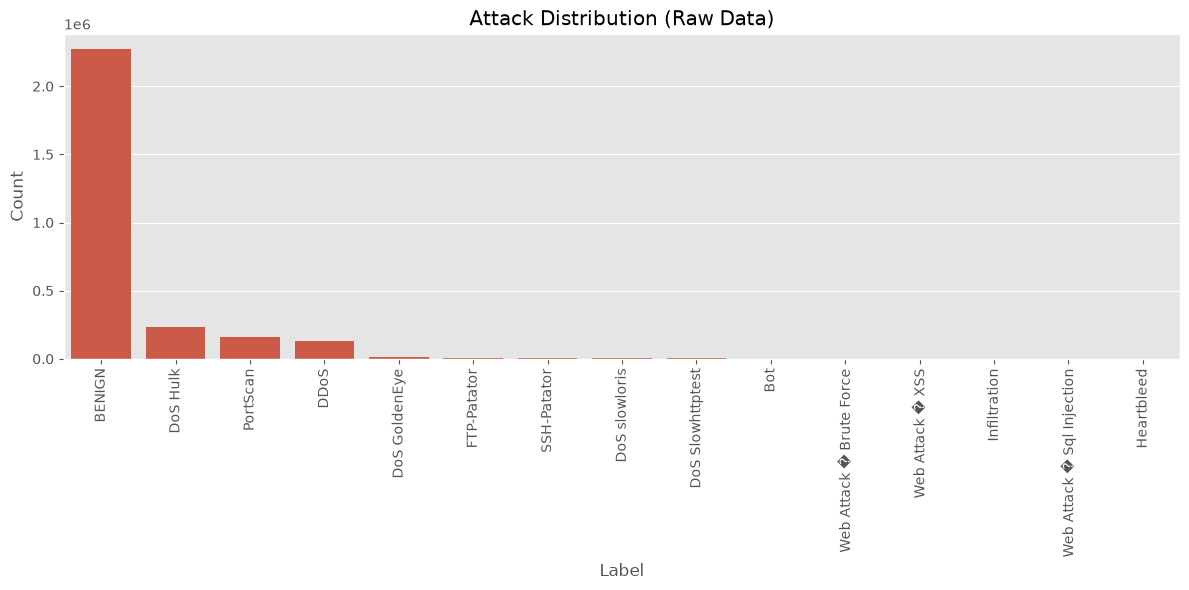

In [11]:

label_counts = df[label_col].value_counts()
print(label_counts)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x=label_col, order=label_counts.index)
plt.xticks(rotation=90)
plt.title("Attack Distribution (Raw Data)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [12]:

# Class imbalance ratio — important to know before choosing the modeling / metric strategy
label_pct = (df[label_col].value_counts(normalize=True) * 100).round(3)
print("Class distribution (%):")
label_pct


Class distribution (%):


Label
BENIGN                        80.300
DoS Hulk                       8.163
PortScan                       5.614
DDoS                           4.523
DoS GoldenEye                  0.364
FTP-Patator                    0.280
SSH-Patator                    0.208
DoS slowloris                  0.205
DoS Slowhttptest               0.194
Bot                            0.069
Web Attack � Brute Force       0.053
Web Attack � XSS               0.023
Infiltration                   0.001
Web Attack � Sql Injection     0.001
Heartbleed                     0.000
Name: proportion, dtype: float64

### 2.5 Data types & memory footprint

In [13]:

print(df.dtypes.value_counts())
mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Dataset memory: {mem_mb:.2f} MB")


int64      54
float64    24
str         1
Name: count, dtype: int64
Dataset memory: 1855.53 MB


### 2.6 Numeric feature distributions & correlation (EDA)

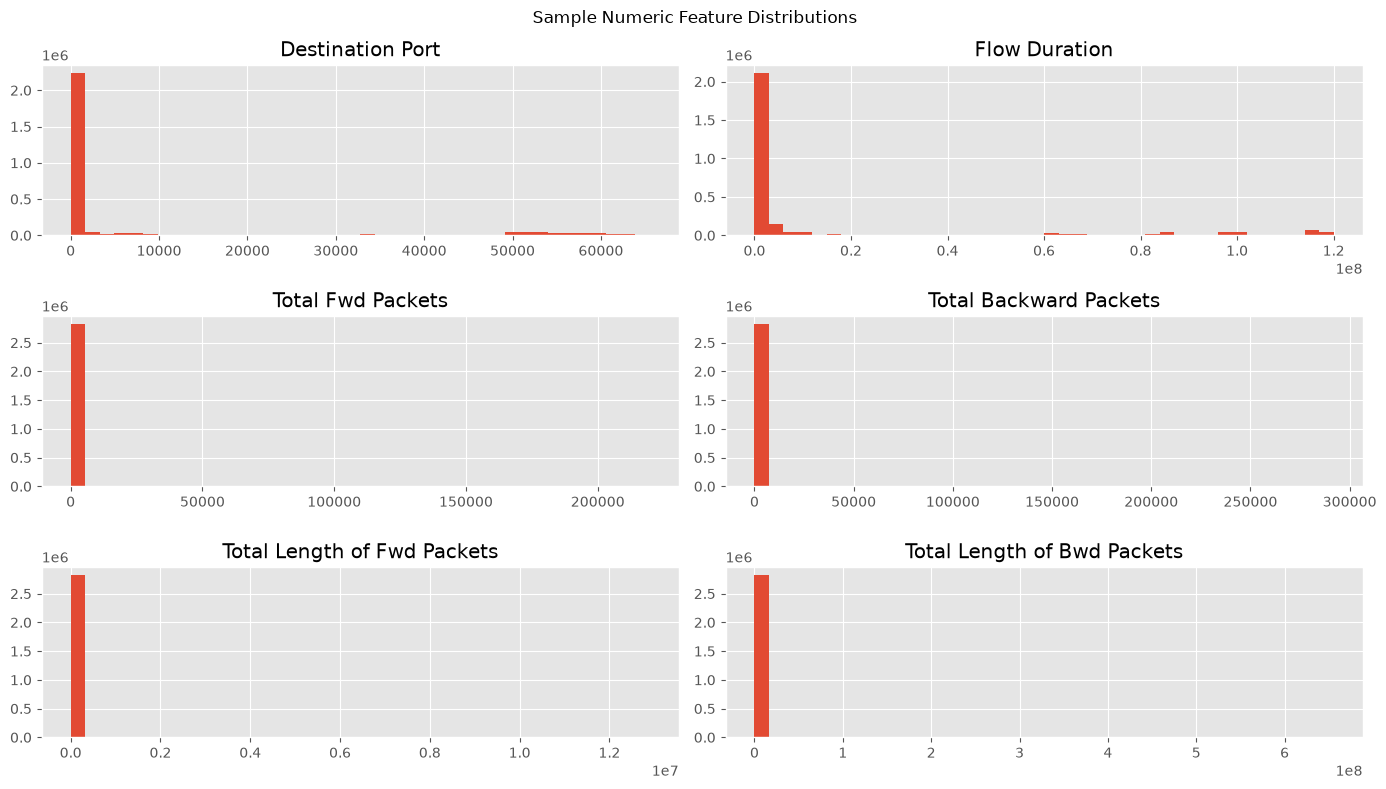

In [14]:

numeric_cols_preview = df.select_dtypes(include=np.number).columns

# Sample a handful of numeric columns for a quick visual sanity check
sample_cols = list(numeric_cols_preview[:6])
if sample_cols:
    df[sample_cols].hist(figsize=(14, 8), bins=40)
    plt.suptitle("Sample Numeric Feature Distributions")
    plt.tight_layout()
    plt.show()


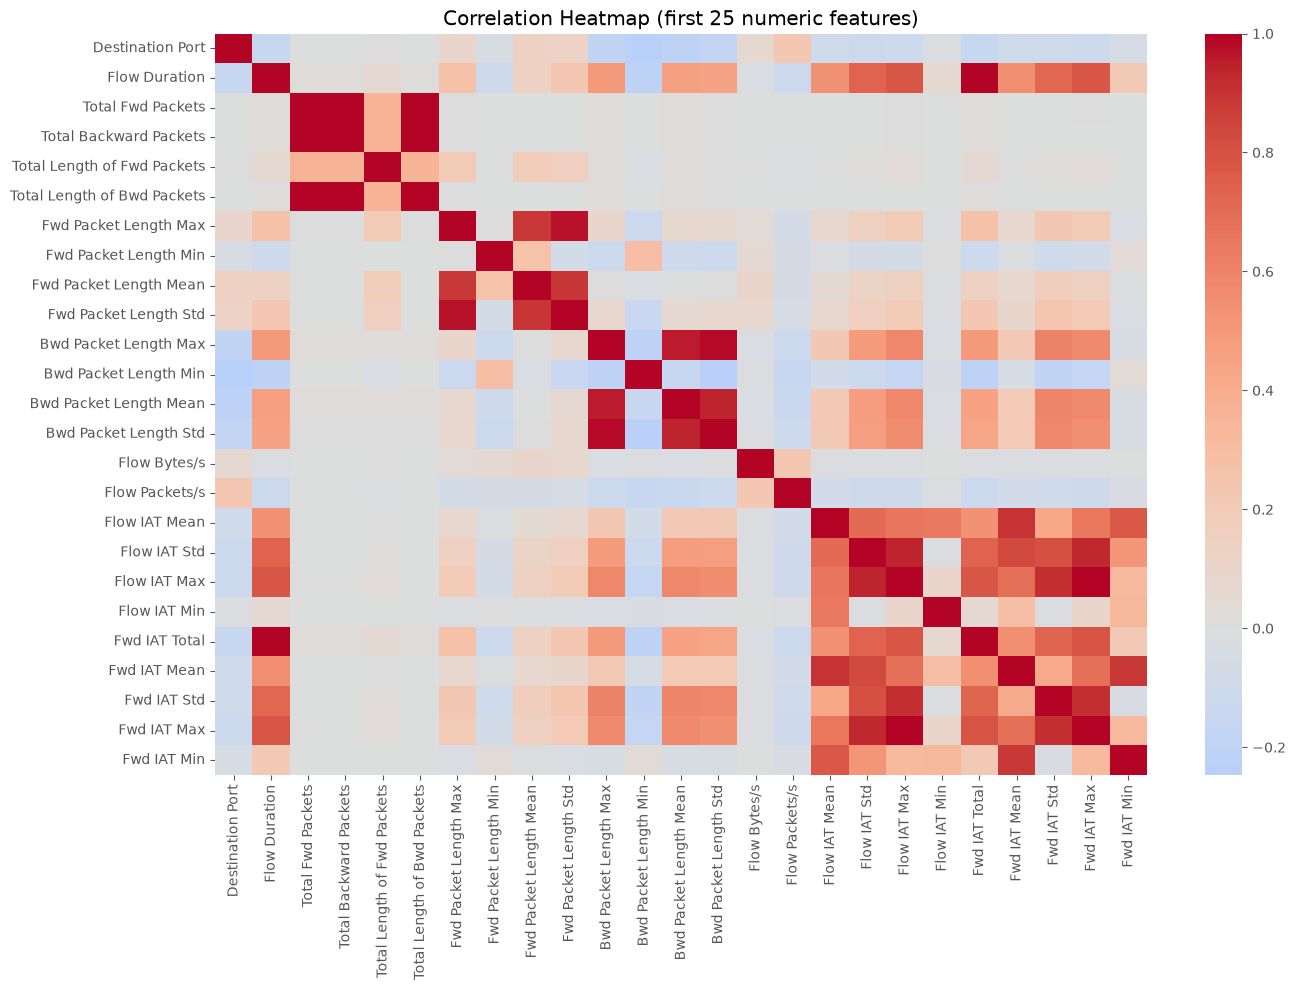

In [15]:

# Correlation heatmap on a subsample of numeric columns (full matrix on 70+ cols is unreadable)
corr_preview_cols = list(numeric_cols_preview[:25])
if len(corr_preview_cols) > 1:
    plt.figure(figsize=(14, 10))
    sns.heatmap(df[corr_preview_cols].corr(), cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap (first 25 numeric features)")
    plt.tight_layout()
    plt.show()


### 2.7 Clean the dataset

In [16]:

clean_df = df.copy()

# --- Remove duplicates ---
before = clean_df.shape[0]
clean_df.drop_duplicates(inplace=True)
clean_df.reset_index(drop=True, inplace=True)
print(f"Removed {before - clean_df.shape[0]} duplicate rows -> {clean_df.shape}")

# --- Replace infinities with NaN (common in NIDS flow-based features, e.g. Flow Bytes/s) ---
numeric_cols = clean_df.select_dtypes(include=np.number).columns
n_inf = np.isinf(clean_df[numeric_cols]).sum().sum()
print(f"Infinite values found: {n_inf}")
clean_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# --- Impute missing numeric values with the median (robust to outliers) ---
clean_df[numeric_cols] = clean_df[numeric_cols].fillna(clean_df[numeric_cols].median())
print("Remaining missing values:", clean_df.isnull().sum().sum())


Removed 308381 duplicate rows -> (2522362, 79)
Infinite values found: 2775
Remaining missing values: 0


In [17]:

# Memory optimization: downcast float64 -> float32, int64 -> int32
for col in clean_df.select_dtypes(include="float64").columns:
    clean_df[col] = clean_df[col].astype("float32")
for col in clean_df.select_dtypes(include="int64").columns:
    clean_df[col] = clean_df[col].astype("int32")

mem_mb_after = clean_df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory after downcast: {mem_mb_after:.2f} MB (was {mem_mb:.2f} MB)")
clean_df.info()


Memory after downcast: 902.70 MB (was 1855.53 MB)
<class 'pandas.DataFrame'>
RangeIndex: 2522362 entries, 0 to 2522361
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int32  
 1   Flow Duration                int32  
 2   Total Fwd Packets            int32  
 3   Total Backward Packets       int32  
 4   Total Length of Fwd Packets  int32  
 5   Total Length of Bwd Packets  int32  
 6   Fwd Packet Length Max        int32  
 7   Fwd Packet Length Min        int32  
 8   Fwd Packet Length Mean       float32
 9   Fwd Packet Length Std        float32
 10  Bwd Packet Length Max        int32  
 11  Bwd Packet Length Min        int32  
 12  Bwd Packet Length Mean       float32
 13  Bwd Packet Length Std        float32
 14  Flow Bytes/s                 float32
 15  Flow Packets/s               float32
 16  Flow IAT Mean                float32
 17  Flow IAT Std                 float32
 18  Flo

In [18]:

clean_path = CONFIG["processed_dir"] / "cleaned_dataset.csv"
clean_df.to_csv(clean_path, index=False)
print("Saved:", clean_path)


Saved: dataset\processed_data\cleaned_dataset.csv


## Phase 3 — Feature Engineering

Steps: separate features/target, drop constant & duplicate columns, drop highly
correlated columns, encode the label, scale numeric features, and persist every
artifact needed for inference later (scaler, encoder, final feature list).


In [19]:

clean_df = pd.read_csv(CONFIG["processed_dir"] / "cleaned_dataset.csv")

X = clean_df.drop(columns=[label_col])
y = clean_df[label_col]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features:  {len(categorical_features)} -> {categorical_features}")


Numeric features:     78
Categorical features:  0 -> []


In [20]:

# --- Drop constant columns (zero information) ---
constant_columns = [c for c in X.columns if X[c].nunique() <= 1]
print(f"Constant columns ({len(constant_columns)}): {constant_columns}")
X.drop(columns=constant_columns, inplace=True)


Constant columns (8): ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [81]:

# --- Drop exact-duplicate columns ---
duplicate_columns = []
cols = X.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if cols[j] not in duplicate_columns and X[cols[i]].equals(X[cols[j]]):
            duplicate_columns.append(cols[j])

print(f"Duplicate columns ({len(duplicate_columns)}): {duplicate_columns}")
X.drop(columns=duplicate_columns, inplace=True)


Duplicate columns (7): ['Subflow Fwd Packets', 'Subflow Bwd Packets', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'SYN Flag Count', 'CWE Flag Count', 'Fwd Header Length.1']


In [82]:

# --- Drop highly correlated columns (keep one of each correlated pair) ---
corr_matrix = X.select_dtypes(include=np.number).corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_cols = [c for c in upper_triangle.columns if any(upper_triangle[c] > CONFIG["corr_threshold"])]
print(f"Highly correlated columns dropped ({len(high_corr_cols)}): {high_corr_cols}")
X.drop(columns=high_corr_cols, inplace=True)

print("Final feature matrix shape:", X.shape)


Highly correlated columns dropped (16): ['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'ECE Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']
Final feature matrix shape: (2522362, 47)


In [83]:

# --- Encode the label ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:")
for k, v in label_mapping.items():
    print(f"  {v}: {k}")


Label mapping:
  0: BENIGN
  1: Bot
  2: DDoS
  3: DoS GoldenEye
  4: DoS Hulk
  5: DoS Slowhttptest
  6: DoS slowloris
  7: FTP-Patator
  8: Heartbleed
  9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack � Brute Force
  13: Web Attack � Sql Injection
  14: Web Attack � XSS


In [84]:

# -------------------------------
# Create two feature sets
# -------------------------------

# Tree-based models
X_tree = X.copy()

# Linear models
scaler = StandardScaler()

X_linear = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print("Tree Dataset :", X_tree.shape)
print("Linear Dataset :", X_linear.shape)


Tree Dataset : (2522362, 47)
Linear Dataset : (2522362, 47)


In [90]:

feature_names = X.columns.tolist()
print(f"Final feature count: {len(feature_names)}")

# --- Persist processed data & artifacts ---
processed_df = X_scaled.copy()
processed_df[label_col] = y_encoded
processed_df.to_csv(CONFIG["processed_dir"] / "final_processed_dataset.csv", index=False)

pd.DataFrame(label_mapping.items(), columns=["Attack_Name", "Encoded_Label"]) \
  .to_csv(CONFIG["processed_dir"] / "label_mapping.csv", index=False)

joblib.dump(scaler, CONFIG["models_dir"] / "scaler.pkl")
joblib.dump(label_encoder, CONFIG["models_dir"] / "label_encoder.pkl")
joblib.dump(feature_names, CONFIG["models_dir"] / "feature_names.pkl")

# Save preprocessing configuration
preprocessing_config = {
    "constant_columns": constant_columns,
    "duplicate_columns": duplicate_columns,
    "high_corr_columns": high_corr_cols
}

joblib.dump(
    preprocessing_config,
    CONFIG["models_dir"] / "preprocessing_config.pkl"
)

print("Feature engineering artifacts saved.")
print("Preprocessing configuration saved.")


Final feature count: 47
Feature engineering artifacts saved.
Preprocessing configuration saved.


## Phase 4 — Train-Test Split

In [86]:
# ------------------------
# Split for Tree Models
# ------------------------

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree,
    y_encoded,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y_encoded
)

# ------------------------
# Split for Linear Models
# ------------------------

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear,
    y_encoded,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y_encoded
)

print("Tree Train :", X_train_tree.shape)
print("Linear Train :", X_train_linear.shape)

print("Training shape :", X_train.shape)
print("Testing shape  :", X_test.shape)
print("Training labels:", len(y_train))
print("Testing labels :", len(y_test))


Tree Train : (2017889, 47)
Linear Train : (2017889, 47)
Training shape : (2017889, 47)
Testing shape  : (504473, 47)
Training labels: 2017889
Testing labels : 504473


## Phase 5 — Model Training (Baselines)

Trains several baseline classifiers with default/light settings to establish a
performance floor before tuning.


In [ ]:

baseline_models = {

    "Logistic Regression": {

        "model": LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

        "train_x": X_train_linear,
        "test_x": X_test_linear,
        "train_y": y_train_linear,
        "test_y": y_test_linear

    },

    "Decision Tree": {

        "model": DecisionTreeClassifier(
            random_state=42
        ),

        "train_x": X_train_tree,
        "test_x": X_test_tree,
        "train_y": y_train_tree,
        "test_y": y_test_tree

    },

    "Random Forest": {

        "model": RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

        "train_x": X_train_tree,
        "test_x": X_test_tree,
        "train_y": y_train_tree,
        "test_y": y_test_tree

    },

    "XGBoost": {

        "model": XGBClassifier(
            random_state=42,
            eval_metric="mlogloss",
            n_estimators=200
        ),

        "train_x": X_train_tree,
        "test_x": X_test_tree,
        "train_y": y_train_tree,
        "test_y": y_test_tree

    }

}

In [89]:
# ============================================================
# Helper Function
# ============================================================

def evaluate_predictions(y_true, y_pred, average="weighted"):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0
        ),
    }


# ============================================================
# Train All Models
# ============================================================

baseline_results = []
trained_models = {}

for name, config in baseline_models.items():

    print("=" * 70)
    print(f"Training Model : {name}")
    print("=" * 70)

    model = config["model"]

    train_x = config["train_x"]
    test_x = config["test_x"]

    train_y = config["train_y"]
    test_y = config["test_y"]

    start = time.time()

    model.fit(train_x, train_y)

    training_time = time.time() - start

    predictions = model.predict(test_x)

    trained_models[name] = model

    metrics = evaluate_predictions(
        test_y,
        predictions
    )

    metrics["Model"] = name
    metrics["Training Time (s)"] = round(training_time, 3)

    baseline_results.append(metrics)

    print(classification_report(
        test_y,
        predictions,
        zero_division=0
    ))


# ============================================================
# Model Comparison
# ============================================================

baseline_results_df = (
    pd.DataFrame(baseline_results)
    [
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "Training Time (s)"
        ]
    ]
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(baseline_results_df)

Training Model : Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.98      0.99    419297
           1       0.67      0.02      0.03       391
           2       1.00      0.97      0.98     25603
           3       0.95      0.80      0.87      2057
           4       1.00      0.95      0.97     34570
           5       0.80      0.75      0.78      1046
           6       0.93      0.88      0.91      1077
           7       0.98      0.99      0.98      1187
           8       1.00      1.00      1.00         2
           9       1.00      0.14      0.25         7
          10       0.72      0.99      0.84     18164
          11       0.98      0.91      0.94       644
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.98    504473
   macro avg       0.73      0.63      0.64

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,Random Forest,0.998341,0.998317,0.998341,0.998324,523.573
1,Decision Tree,0.998061,0.998094,0.998061,0.998073,152.015
2,XGBoost,0.994299,0.994266,0.994299,0.994280,635.709
3,Logistic Regression,0.976486,0.978937,0.976486,0.976613,557.472


## Phase 6 — Model Evaluation (Baselines)

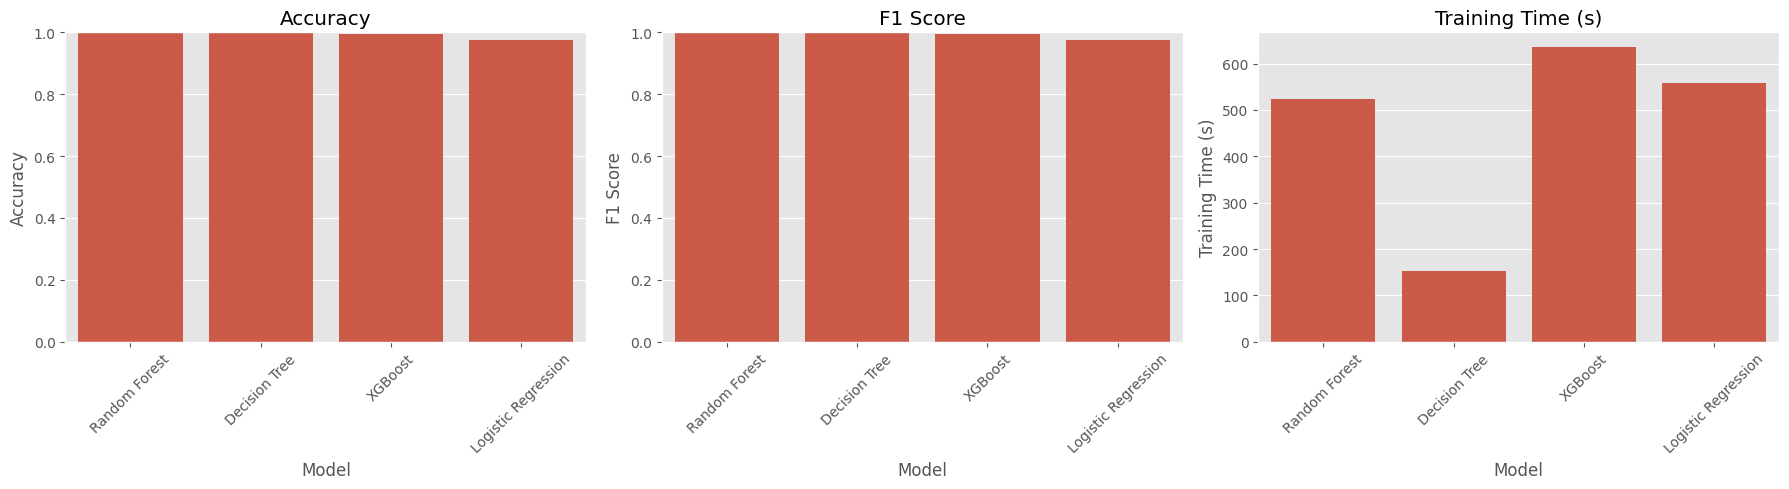

In [91]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=baseline_results_df, x="Model", y="Accuracy", ax=axes[0])
axes[0].set_ylim(0, 1); axes[0].set_title("Accuracy"); axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=baseline_results_df, x="Model", y="F1 Score", ax=axes[1])
axes[1].set_ylim(0, 1); axes[1].set_title("F1 Score"); axes[1].tick_params(axis="x", rotation=45)

sns.barplot(data=baseline_results_df, x="Model", y="Training Time (s)", ax=axes[2])
axes[2].set_title("Training Time (s)"); axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [92]:

# Pick the champion baseline model to carry forward into tuning
champion_name = baseline_results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]
champion_model = trained_models[champion_name]
print("Champion baseline model:", champion_name)


Champion baseline model: Random Forest


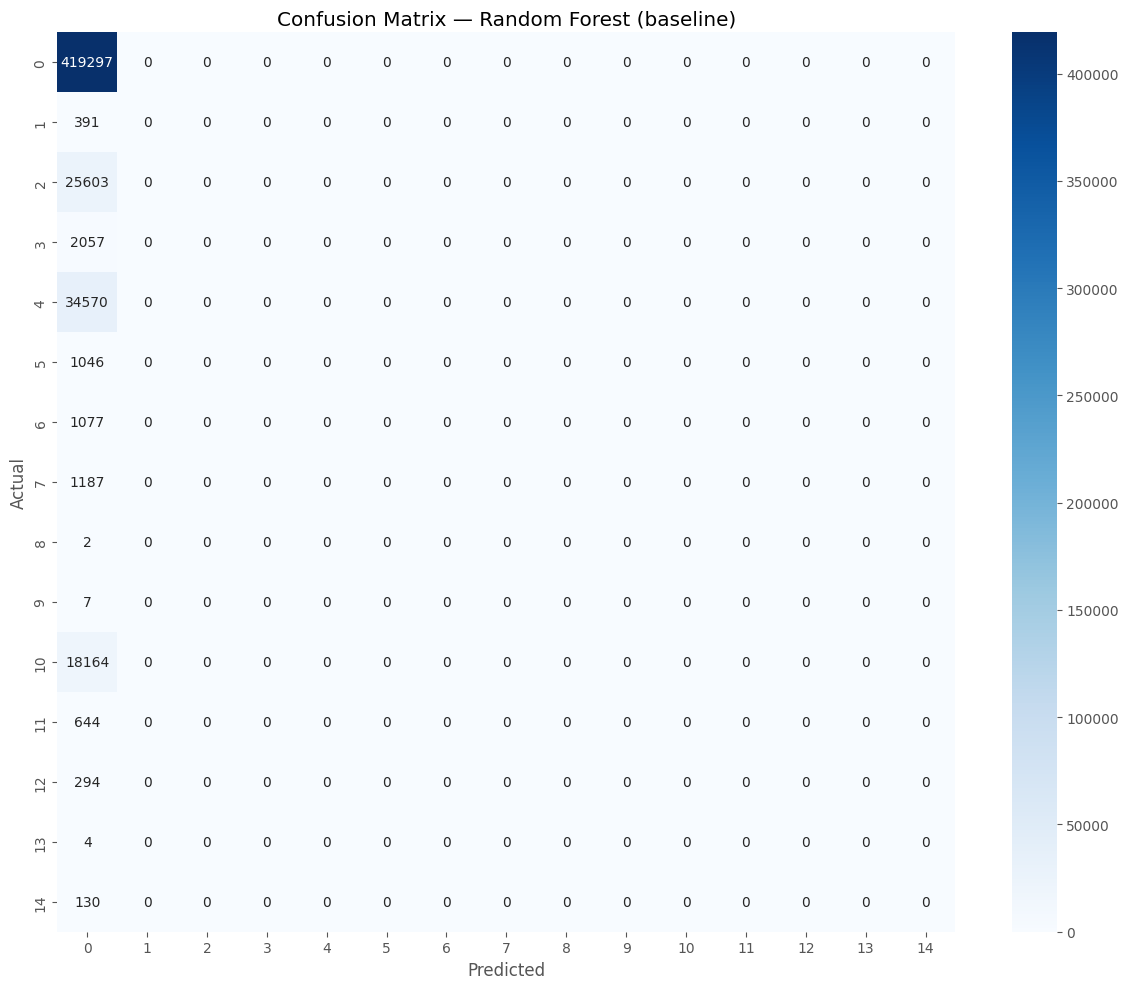

In [93]:

preds = champion_model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {champion_name} (baseline)")
plt.tight_layout()
plt.show()


## Phase 7 — Hyperparameter Tuning ⭐

`RandomizedSearchCV` is used instead of an exhaustive `GridSearchCV` because NIDS
datasets are large and grid search over many hyperparameters is computationally
prohibitive. Stratified k-fold cross-validation preserves the (often severe) class
imbalance across folds.

The search space below targets **XGBoost** by default since gradient-boosted trees
are typically the strongest performer for tabular NIDS data; swap in the
`param_distributions` for Random Forest if that was your champion baseline instead.


In [94]:

cv_strategy = StratifiedKFold(
    n_splits=CONFIG["n_cv_folds"], shuffle=True, random_state=CONFIG["random_state"]
)

if champion_name == "XGBoost":
    tuning_estimator = XGBClassifier(
        random_state=CONFIG["random_state"],
        eval_metric="mlogloss",
        n_jobs=-1,
        tree_method="hist",   # memory-efficient histogram splitting, not exact/dense
    )
    param_distributions = {
        "n_estimators": [100, 200, 300, 400],
        "max_depth": [3, 5, 7, 9],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
    }
elif champion_name == "Random Forest":
    tuning_estimator = RandomForestClassifier(random_state=CONFIG["random_state"], n_jobs=-1)
    param_distributions = {
        "n_estimators": [100, 200, 300, 400],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
    }
elif champion_name == "Decision Tree":
    tuning_estimator = DecisionTreeClassifier(random_state=CONFIG["random_state"])
    param_distributions = {
        "max_depth": [None, 5, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"],
    }
else:  # Logistic Regression
    tuning_estimator = LogisticRegression(max_iter=2000, random_state=CONFIG["random_state"])
    param_distributions = {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs", "saga"],
    }

print("Tuning estimator:", tuning_estimator.__class__.__name__)
print("Search space:", json.dumps(param_distributions, indent=2))


Tuning estimator: RandomForestClassifier
Search space: {
  "n_estimators": [
    100,
    200,
    300,
    400
  ],
  "max_depth": [
    null,
    10,
    20,
    30
  ],
  "min_samples_split": [
    2,
    5,
    10
  ],
  "min_samples_leaf": [
    1,
    2,
    4
  ],
  "max_features": [
    "sqrt",
    "log2"
  ]
}


In [95]:
# --- Subsample for the search itself (memory safety) ---
# Full X_train may be millions of rows; searching directly on it with process-based
# parallelism is what caused the MemoryError. Search on a stratified subsample instead.
if X_train.shape[0] > CONFIG["hpo_sample_size"]:
    X_hpo, _, y_hpo, _ = train_test_split(
        X_train, y_train,
        train_size=CONFIG["hpo_sample_size"],
        random_state=CONFIG["random_state"],
        stratify=y_train,
    )
    print(f"Searching on a stratified subsample: {X_hpo.shape[0]:,} of {X_train.shape[0]:,} rows")
else:
    X_hpo, y_hpo = X_train, y_train

random_search = RandomizedSearchCV(
    estimator=tuning_estimator,
    param_distributions=param_distributions,
    n_iter=CONFIG["hpo_n_iter"],
    scoring="f1_weighted",
    cv=cv_strategy,
    random_state=CONFIG["random_state"],
    n_jobs=CONFIG["hpo_n_jobs"],   # LOW on purpose -- see memory-safety note above
    verbose=1,
)

start = time.time()
random_search.fit(X_hpo, y_hpo)
tuning_time = time.time() - start

print(f"Hyperparameter search completed in {tuning_time:.1f}s")
print("Best CV F1 (weighted) on subsample:", random_search.best_score_)
print("Best params:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")


Searching on a stratified subsample: 150,000 of 2,017,889 rows
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Hyperparameter search completed in 3960.3s
Best CV F1 (weighted) on subsample: 0.997677125188465
Best params:
  n_estimators: 200
  min_samples_split: 5
  min_samples_leaf: 1
  max_features: sqrt
  max_depth: None


In [96]:

best_model = random_search.best_estimator_

# Save the full CV results for auditability
cv_results_df = pd.DataFrame(random_search.cv_results_).sort_values("rank_test_score")
cv_results_df.to_csv(CONFIG["reports_dir"] / "hyperparameter_search_results.csv", index=False)
cv_results_df.head(10)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
]


,params,mean_test_score,std_test_score,rank_test_score
16,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.997677,0.000263,1
15,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.997629,0.000225,2
2,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.997628,0.000234,3
3,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.997625,0.000199,4
10,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.997625,0.000325,5
4,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.997598,0.000265,6
17,"{'n_estimators': 100, 'min_samples_split': 10,...",0.997546,0.000207,7
5,"{'n_estimators': 200, 'min_samples_split': 10,...",0.997542,0.000263,8
6,"{'n_estimators': 300, 'min_samples_split': 10,...",0.997505,0.000331,9
0,"{'n_estimators': 200, 'min_samples_split': 10,...",0.997476,0.000279,10


## Phase 8 — Final Model Evaluation (Tuned Model)

In [97]:

y_pred_tuned = best_model.predict(X_test)

tuned_metrics = evaluate_predictions(y_test, y_pred_tuned)
print("Tuned model performance:")
for k, v in tuned_metrics.items():
    print(f"  {k}: {v:.4f}")

print()
print(classification_report(y_test, y_pred_tuned, zero_division=0))


Tuned model performance:
  Accuracy: 0.9980
  Precision: 0.9979
  Recall: 0.9980
  F1 Score: 0.9979

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419297
           1       0.84      0.52      0.64       391
           2       1.00      1.00      1.00     25603
           3       0.99      0.98      0.98      2057
           4       1.00      1.00      1.00     34570
           5       0.98      0.98      0.98      1046
           6       1.00      0.98      0.99      1077
           7       1.00      0.99      1.00      1187
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.99      1.00      0.99     18164
          11       1.00      0.97      0.99       644
          12       0.71      0.72      0.72       294
          13       0.00      0.00      0.00         4
          14       0.43      0.32      0.36       130

    accuracy                     

In [98]:

# Before vs. after comparison
comparison_df = pd.DataFrame([
    {"Stage": f"Baseline ({champion_name})", **evaluate_predictions(y_test, champion_model.predict(X_test))},
    {"Stage": f"Tuned ({champion_name})", **tuned_metrics},
])
comparison_df


,Stage,Accuracy,Precision,Recall,F1 Score
0,Baseline (Random Forest),0.831158,0.690824,0.831158,0.754522
1,Tuned (Random Forest),0.998010,0.997905,0.998010,0.997923


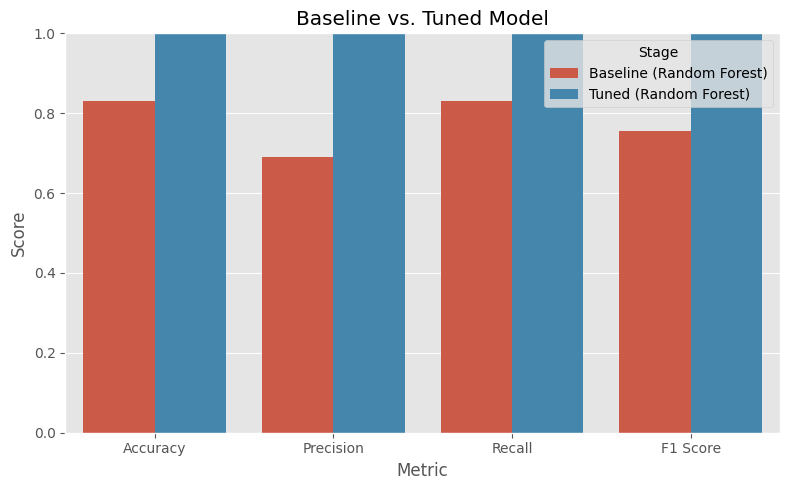

In [99]:

plt.figure(figsize=(8, 5))
comparison_melted = comparison_df.melt(id_vars="Stage", var_name="Metric", value_name="Score")
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Stage")
plt.ylim(0, 1)
plt.title("Baseline vs. Tuned Model")
plt.tight_layout()
plt.show()


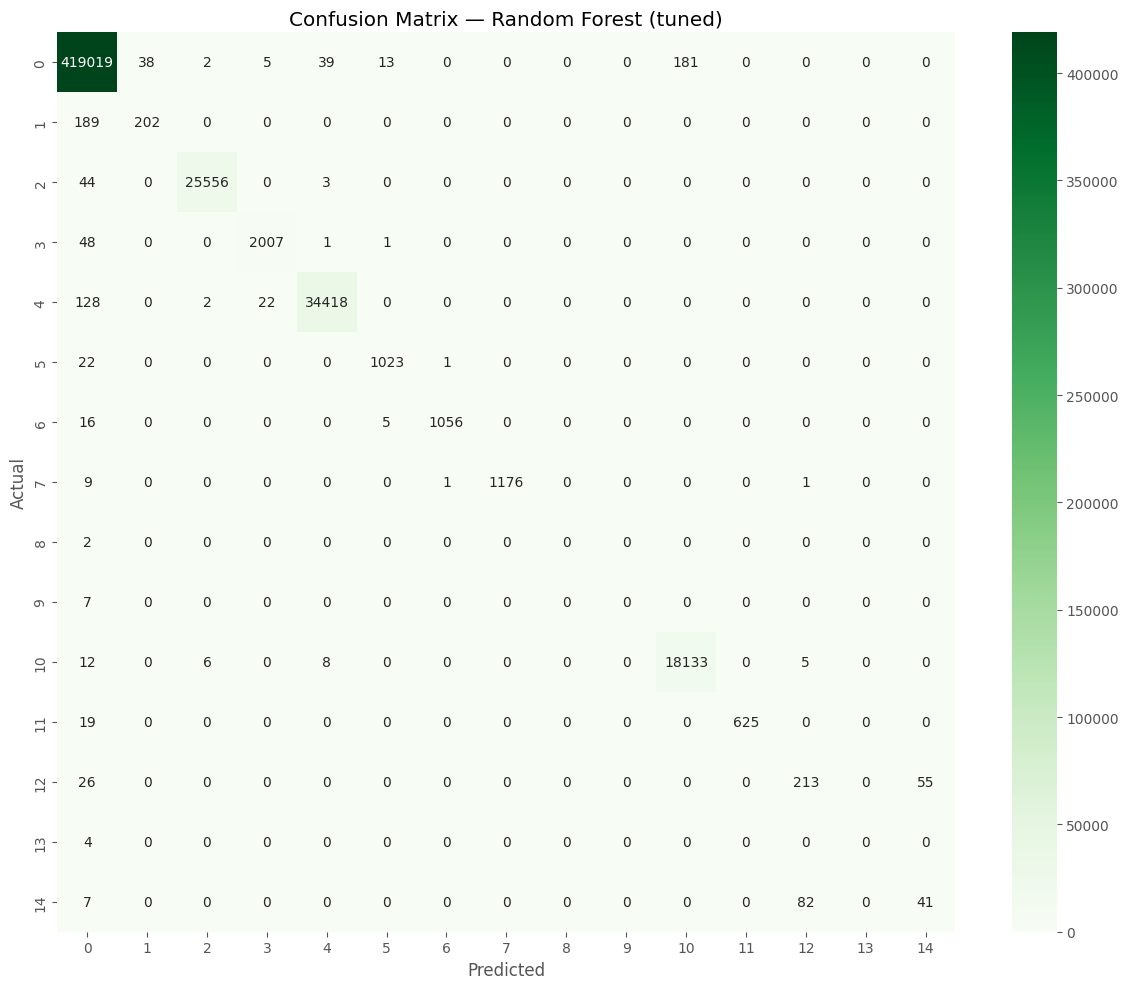

In [100]:

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {champion_name} (tuned)")
plt.tight_layout()
plt.show()


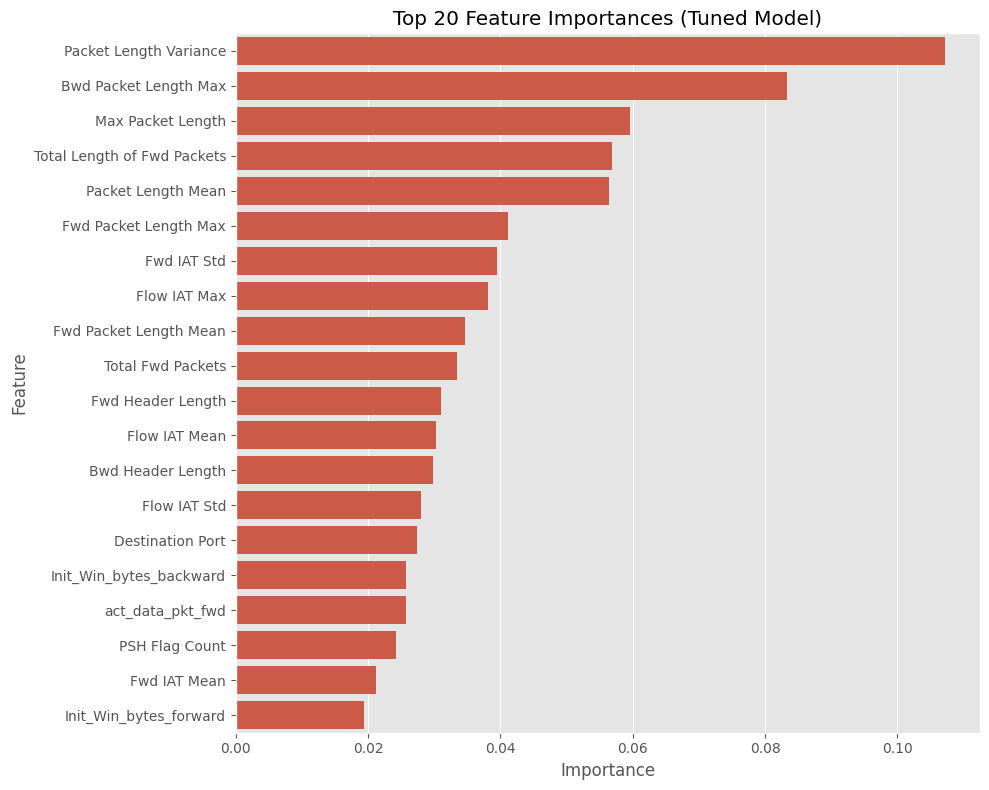

In [101]:

# Feature importance (tree-based models expose this natively)
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": best_model.feature_importances_,
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df.head(20), x="Importance", y="Feature")
    plt.title("Top 20 Feature Importances (Tuned Model)")
    plt.tight_layout()
    plt.show()

    importance_df.to_csv(CONFIG["reports_dir"] / "feature_importance.csv", index=False)


Running final CV on a stratified subsample: 200,000 of 2,522,362 rows


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:   52.4s finished


CV completed in 52.8s
Per-fold accuracy: [0.99803501 0.99818501 0.99782498]
Mean CV accuracy : 0.998014999049896


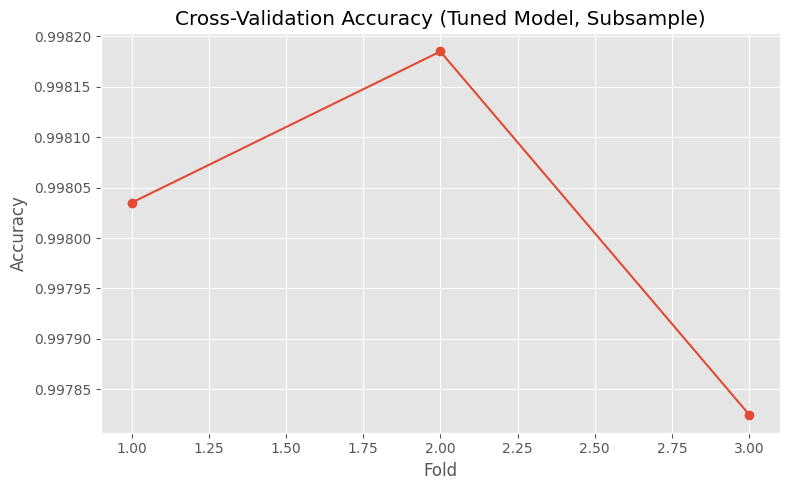

In [102]:

# --- Final CV sanity check (memory- AND time-safe version) ---
# Running 5-fold CV on the FULL multi-million-row dataset means 5 full refits of
# the model -- that's what was taking hours. This is only a robustness sanity
# check (the real evaluation already happened on X_test in Phase 8), so run it
# on a stratified subsample with fewer folds instead.

CONFIG["final_cv_sample_size"] = 200_000  # tune down further (e.g. 50_000) if still slow
CONFIG["final_cv_folds"] = 3

if X_scaled.shape[0] > CONFIG["final_cv_sample_size"]:
    X_cv, _, y_cv, _ = train_test_split(
        X_scaled, y_encoded,
        train_size=CONFIG["final_cv_sample_size"],
        random_state=CONFIG["random_state"],
        stratify=y_encoded,
    )
    print(f"Running final CV on a stratified subsample: {X_cv.shape[0]:,} of {X_scaled.shape[0]:,} rows")
else:
    X_cv, y_cv = X_scaled, y_encoded

start = time.time()
cv_scores = cross_val_score(
    best_model, X_cv, y_cv,
    cv=CONFIG["final_cv_folds"],
    scoring="accuracy",
    n_jobs=CONFIG["hpo_n_jobs"],
    verbose=2,          # prints progress per fold so you can see it's alive, not hung
)
print(f"CV completed in {time.time() - start:.1f}s")

print("Per-fold accuracy:", cv_scores)
print("Mean CV accuracy :", cv_scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker="o")
plt.xlabel("Fold"); plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy (Tuned Model, Subsample)")
plt.grid(True)
plt.tight_layout()
plt.show()

Threat Severity Scoring

In [103]:
probabilities = best_model.predict_proba(X_test_tree)

confidence = probabilities.max(axis=1)

severity = []

for score in confidence:

    if score < 0.50:

        severity.append("Low")

    elif score < 0.70:

        severity.append("Medium")

    elif score < 0.90:

        severity.append("High")

    else:

        severity.append("Critical")

In [104]:
prediction_labels = label_encoder.inverse_transform(
    y_pred_tuned
)

results = pd.DataFrame({

    "Prediction": prediction_labels,

    "Confidence": confidence,

    "Severity": severity

})

results.head()

,Prediction,Confidence,Severity
0,DDoS,0.764321,High
1,BENIGN,0.863655,High
2,BENIGN,0.656042,Medium
3,BENIGN,0.805738,High
4,BENIGN,0.628542,Medium


In [105]:
results.to_csv(

    CONFIG["reports_dir"] /

    "prediction_results.csv",

    index=False

)

In [106]:
recommendations = {

    "BENIGN":
        "No Action Required",

    "DoS Hulk":
        "Block Source IP",

    "DDoS":
        "Block Source IP Immediately",

    "PortScan":
        "Monitor Source Host",

    "Bot":
        "Quarantine Device",

    "FTP-Patator":
        "Reset FTP Credentials",

    "SSH-Patator":
        "Reset SSH Credentials",

    "Web Attack – Brute Force":
        "Lock User Account",

    "Web Attack – XSS":
        "Sanitize User Input",

    "Web Attack – SQL Injection":
        "Block SQL Requests",

    "Infiltration":
        "Disconnect Device"

}

results["Recommendation"] = results["Prediction"].map(
    recommendations
)

results.head()

,Prediction,Confidence,Severity,Recommendation
0,DDoS,0.764321,High,Block Source IP Immediately
1,BENIGN,0.863655,High,No Action Required
2,BENIGN,0.656042,Medium,No Action Required
3,BENIGN,0.805738,High,No Action Required
4,BENIGN,0.628542,Medium,No Action Required


## Phase 9 — Explainable AI (SHAP)

SHAP (SHapley Additive exPlanations) attributes each prediction to its contributing
features — critical for a NIDS model, where analysts need to justify *why* traffic
was flagged as an attack. `TreeExplainer` is used since tree-based models
(Random Forest / XGBoost / Decision Tree) are exact and fast with SHAP; a
`KernelExplainer` fallback is provided for linear models.

For speed on large NIDS datasets, SHAP values are computed on a random subsample.


In [107]:
import sys
print(sys.executable)

c:\Users\Saurabh suman\Downloads\Telegram Desktop\python.exe


In [108]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [109]:

try:
    import shap
except ImportError:
    %pip install shap
    import shap

shap.initjs()


In [110]:

sample_size = min(CONFIG["shap_sample_size"], X_test.shape[0])
X_shap_sample = X_test.sample(n=sample_size, random_state=CONFIG["random_state"])

is_tree_model = best_model.__class__.__name__ in (
    "XGBClassifier", "RandomForestClassifier", "DecisionTreeClassifier"
)

if is_tree_model:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap_sample)
else:
    background = X_train.sample(n=min(100, X_train.shape[0]), random_state=CONFIG["random_state"])
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_shap_sample)

print("SHAP values computed on", sample_size, "samples.")


SHAP values computed on 2000 samples.


<Figure size 640x480 with 0 Axes>

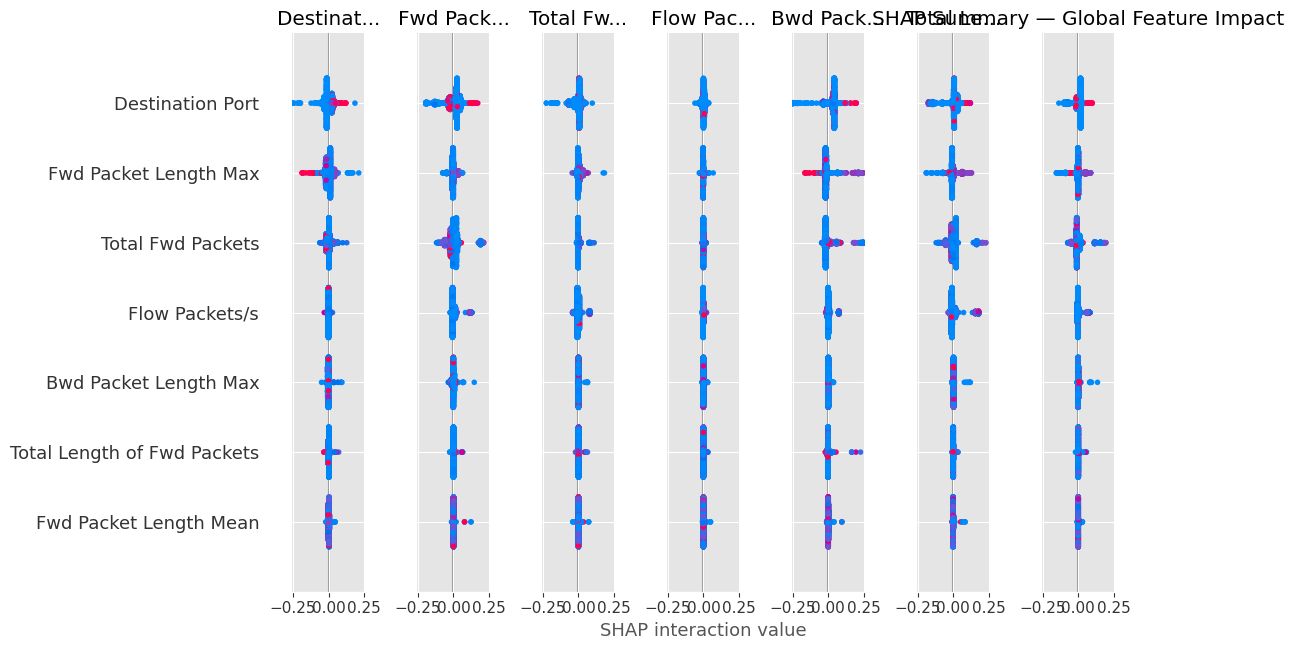

In [111]:

# Global feature importance — summary plot
# For multiclass models shap_values is a list (one array per class); average |SHAP| across classes.
plt.figure()
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    shap.summary_plot(mean_abs_shap, X_shap_sample, show=False)
else:
    shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title("SHAP Summary — Global Feature Impact")
plt.tight_layout()
plt.show()


Explaining prediction for sample #0 -> predicted class: BENIGN


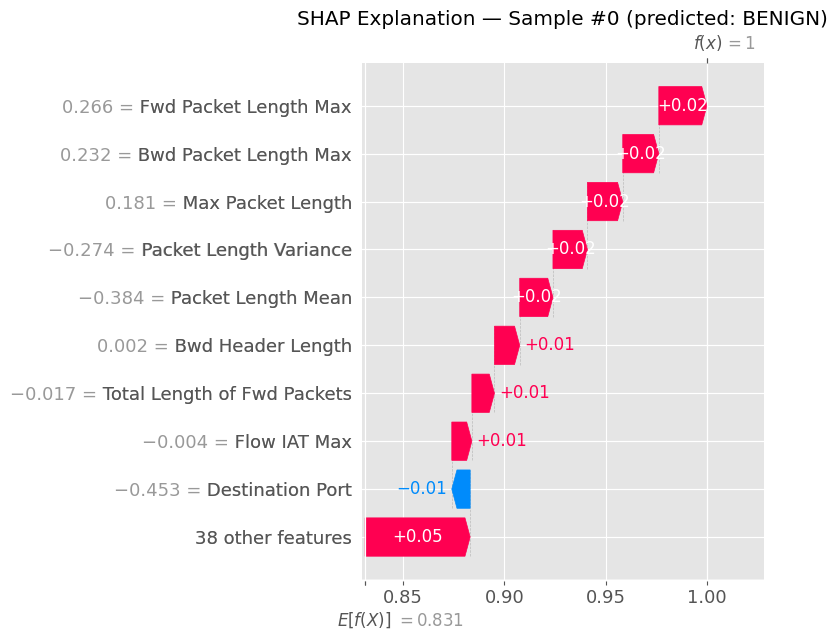

In [112]:
sample_idx = 0
sample_row = X_shap_sample.iloc[[sample_idx]]
predicted_class = best_model.predict(sample_row)[0]
predicted_label = label_encoder.inverse_transform([predicted_class])[0]
print(f"Explaining prediction for sample #{sample_idx} -> predicted class: {predicted_label}")

if isinstance(shap_values, list):
    class_idx = predicted_class
    sample_shap = shap_values[class_idx][sample_idx, :]
    base_value = explainer.expected_value[class_idx]

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    class_idx = predicted_class
    sample_shap = shap_values[sample_idx, :, class_idx]
    base_value = (
        explainer.expected_value[class_idx]
        if hasattr(explainer.expected_value, "__len__")
        else explainer.expected_value
    )

else:
    sample_shap = shap_values[sample_idx, :]
    base_value = (
        explainer.expected_value[0]
        if hasattr(explainer.expected_value, "__len__")
        else explainer.expected_value
    )

explanation = shap.Explanation(
    values=sample_shap,
    base_values=base_value,
    data=sample_row.values[0],
    feature_names=X_shap_sample.columns.tolist(),
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Explanation — Sample #{sample_idx} (predicted: {predicted_label})")
plt.tight_layout()
plt.show()

In [113]:
# Persist a static SHAP feature-ranking report (useful for security analysts / audits)
# shap_values can be:
#   - a list of (n_samples, n_features) arrays, one per class
#   - a single (n_samples, n_features, n_classes) ndarray
#   - a single (n_samples, n_features) ndarray (binary / regression)
# In all cases we want one final (n_features,) array: mean absolute SHAP value
# per feature, averaged over samples AND (if present) classes.

if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)  # -> (n_samples, n_features)
    feature_importance = mean_abs_shap.mean(axis=0)                       # -> (n_features,)

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    mean_abs_shap = np.abs(shap_values)                 # -> (n_samples, n_features, n_classes)
    feature_importance = mean_abs_shap.mean(axis=(0, 2))  # average over samples AND classes -> (n_features,)

else:
    mean_abs_shap = np.abs(shap_values)   # -> (n_samples, n_features)
    feature_importance = mean_abs_shap.mean(axis=0)  # -> (n_features,)

shap_importance_df = pd.DataFrame({
    "Feature": X_shap_sample.columns,
    "Mean |SHAP value|": feature_importance,
}).sort_values(by="Mean |SHAP value|", ascending=False)

shap_importance_df.to_csv(CONFIG["reports_dir"] / "shap_feature_importance.csv", index=False)
shap_importance_df.head(20)

,Feature,Mean |SHAP value|
31,Packet Length Variance,0.005620
7,Bwd Packet Length Max,0.004525
4,Fwd Packet Length Max,0.003622
0,Destination Port,0.003377
29,Max Packet Length,0.003360
30,Packet Length Mean,0.003260
3,Total Length of Fwd Packets,0.003012
6,Fwd Packet Length Mean,0.002093
34,PSH Flag Count,0.002071
39,Init_Win_bytes_backward,0.001871


## Phase 10 — Save Model & Artifacts

Everything needed to reproduce inference in production is saved together:
the tuned model, scaler, label encoder, final feature list, best hyperparameters,
and a metrics summary.


In [114]:

model_path = CONFIG["models_dir"] / f"nids_best_model_{champion_name.replace(' ', '_').lower()}.pkl"
joblib.dump(best_model, model_path)
print("Saved tuned model to:", model_path)

# scaler.pkl / label_encoder.pkl / feature_names.pkl were already saved in Phase 3.


Saved tuned model to: models\nids_best_model_random_forest.pkl


In [115]:
def to_native(obj):
    """Recursively convert numpy/pandas types to plain Python types so the
    JSON file contains real numbers/strings/bools instead of stringified
    numpy values (which json.dump(default=str) would otherwise produce silently)."""
    if isinstance(obj, dict):
        return {to_native(k): to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_native(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return to_native(obj.tolist())
    if isinstance(obj, np.bool_):
        return bool(obj)
    return obj


# Guard against cv_scores not existing yet (e.g. that cell was interrupted or
# the kernel was restarted after it ran) instead of hard-crashing this cell.
if "cv_scores" in dir() or "cv_scores" in globals():
    cv_mean_accuracy = float(cv_scores.mean())
    cv_std_accuracy = float(cv_scores.std())
else:
    print("WARNING: cv_scores not found -- run the cross-validation cell (Phase 8) "
          "before this one. Saving summary with cv metrics as null for now.")
    cv_mean_accuracy = None
    cv_std_accuracy = None

final_summary = to_native({
    "champion_baseline": champion_name,
    "best_hyperparameters": random_search.best_params_,
    "test_set_metrics": tuned_metrics,
    "cv_mean_accuracy": cv_mean_accuracy,
    "cv_std_accuracy": cv_std_accuracy,
    "n_features": len(feature_names),
    "n_train_samples": int(X_train.shape[0]),
    "n_test_samples": int(X_test.shape[0]),
    "label_mapping": label_mapping,
    "random_state": CONFIG["random_state"],
})

with open(CONFIG["reports_dir"] / "final_model_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)

print(json.dumps(final_summary, indent=2))

{
  "champion_baseline": "Random Forest",
  "best_hyperparameters": {
    "n_estimators": 200,
    "min_samples_split": 5,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "max_depth": null
  },
  "test_set_metrics": {
    "Accuracy": 0.9980098042908144,
    "Precision": 0.9979045208813052,
    "Recall": 0.9980098042908144,
    "F1 Score": 0.9979233072720213
  },
  "cv_mean_accuracy": 0.998014999049896,
  "cv_std_accuracy": 0.000147661486983505,
  "n_features": 47,
  "n_train_samples": 2017889,
  "n_test_samples": 504473,
  "label_mapping": {
    "BENIGN": 0,
    "Bot": 1,
    "DDoS": 2,
    "DoS GoldenEye": 3,
    "DoS Hulk": 4,
    "DoS Slowhttptest": 5,
    "DoS slowloris": 6,
    "FTP-Patator": 7,
    "Heartbleed": 8,
    "Infiltration": 9,
    "PortScan": 10,
    "SSH-Patator": 11,
    "Web Attack \ufffd Brute Force": 12,
    "Web Attack \ufffd Sql Injection": 13,
    "Web Attack \ufffd XSS": 14
  },
  "random_state": 42
}


In [116]:

print("=" * 60)
print("PIPELINE COMPLETE")
print("=" * 60)
print(f"Final model      : {model_path}")
print(f"Scaler           : {CONFIG['models_dir'] / 'scaler.pkl'}")
print(f"Label encoder    : {CONFIG['models_dir'] / 'label_encoder.pkl'}")
print(f"Feature list     : {CONFIG['models_dir'] / 'feature_names.pkl'}")
print(f"Metrics summary  : {CONFIG['reports_dir'] / 'final_model_summary.json'}")
print(f"SHAP report      : {CONFIG['reports_dir'] / 'shap_feature_importance.csv'}")


PIPELINE COMPLETE
Final model      : models\nids_best_model_random_forest.pkl
Scaler           : models\scaler.pkl
Label encoder    : models\label_encoder.pkl
Feature list     : models\feature_names.pkl
Metrics summary  : reports\final_model_summary.json
SHAP report      : reports\shap_feature_importance.csv
